<a href="https://colab.research.google.com/github/a01067863-max/Gemelo-Digital-Rover-TO/blob/main/S2_Primera_Red_JAVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

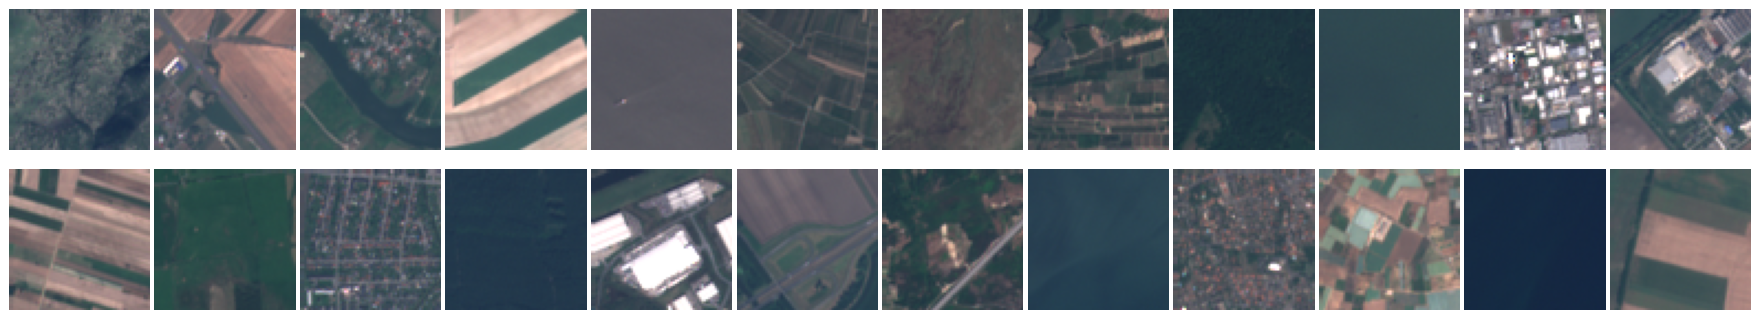

<font size=10>**Proyecto Semana 2**</font>

<font size=6>**Tu primera red neuronal**</font>

# **Problema de negocio - Distinguir lo que se ve igual**

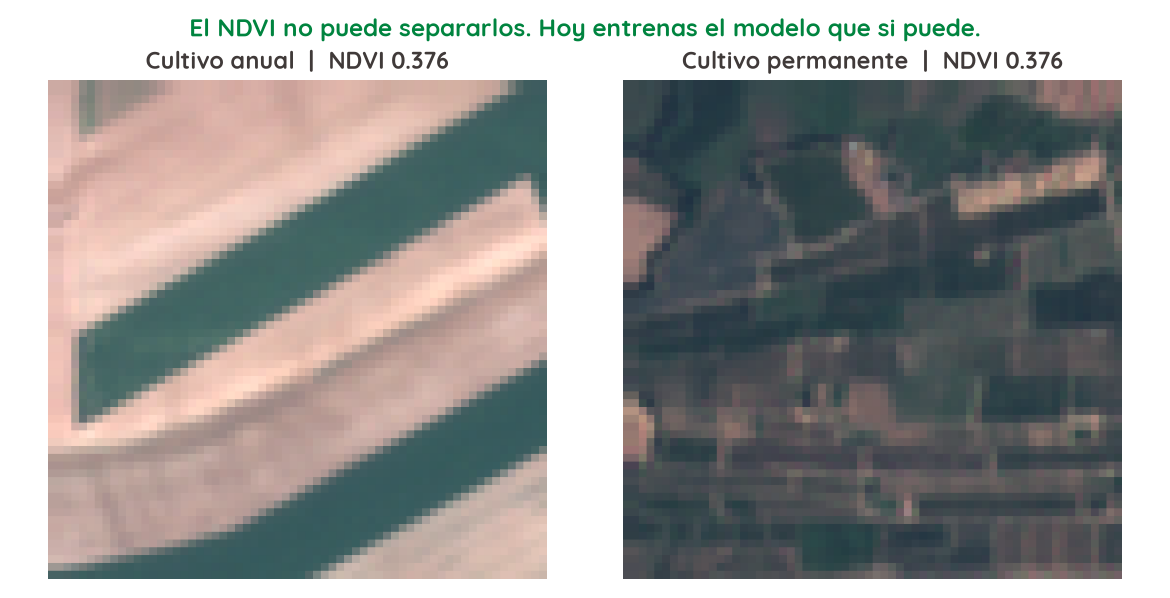

La semana pasada, **Paola** y tu descubrieron algo incomodo: el NDVI, el indice mas famoso de la agricultura satelital, **empata** al cultivo anual con el permanente (0.376 y 0.376). Para Smartgrow esa diferencia importa muchisimo: un huerto de aguacate y una parcela de maiz se manejan, se riegan y se venden completamente distinto.

La buena noticia: hay una herramienta que SI puede separarlos, porque no mira un solo numero sino **la imagen completa con sus 13 bandas**: una red neuronal. Hoy vas a entrenar dos con tus propias manos, y vas a descubrir el truco que usa toda la industria: el **transfer learning**.

### **El caso de estudio**

1. **Apostar** - antes de entrenar, vas a predecir cuanto acertara cada red. Al final comparamos tu ojo contra la realidad.
2. **Entrenar desde cero** - una ResNet-18 que nunca ha visto una imagen en su vida.
3. **Entrenar con ventaja** - la misma red, pero preentrenada con 1.2 millones de fotos (ImageNet).
4. **Comparar con rigor** - mismos datos, mismo split, misma tabla. La diferencia que veas es real.

**Tu ruta en este notebook:**

1. **Preparar el entorno** - hoy la GPU SI es obligatoria.
2. **Elegir el modo** - completo (GPU) o rapido (para probar).
3. **Construir el dataset** - de tensores de 13 bandas a imagenes que la red entiende.
4. **Apuesta 1 y linea base** - cuanto acierta una red SIN entrenar?
5. **Entrenar desde cero** - tu primera corrida real.
6. **Apuesta 2 y transfer learning** - la revancha con ventaja.
7. **El veredicto** - tabla comparativa y tus conclusiones.

### **Objetivo**

Al terminar vas a poder:

1. **Convertir** imagenes satelitales de 13 bandas en tensores listos para una red.
2. **Completar** el loop de entrenamiento (las 3 lineas que hacen la magia).
3. **Entrenar** y comparar dos redes con el mismo split y la misma tabla.
4. **Explicar** con tus numeros por que casi nadie entrena desde cero.

**Tiempo estimado:** 2 a 3 horas (los entrenamientos corren solos unos minutos). Registra tus horas en `hours.csv` con link a tu commit.

# **Preparacion del entorno**

**Que hay que hacer?**

- Abre este notebook en **Google Colab**.
- Activa la GPU: menu **Entorno de ejecucion**, **Cambiar tipo de entorno de ejecucion**, elige **T4 GPU** y guarda. **Esta semana es obligatoria:** sin GPU, el modo completo tardaria horas.
- Ejecuta las celdas en orden, de arriba hacia abajo.

In [25]:
# @title Instalar TorchGeo (2 a 3 minutos; es normal ver mucho texto)
!pip install -q torchgeo

In [26]:
# @title Importar librerias y verificar la GPU
import torch, torchgeo, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torchgeo:", torchgeo.__version__)
print("Dispositivo:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Todo listo para el modo completo.")
else:
    print("AVISO IMPORTANTE: no hay GPU activa.")
    print("Puedes probar el notebook en modo rapido, pero la ENTREGA se hace en modo completo con GPU.")

torchgeo: 0.10.0
Dispositivo: cuda
GPU: Tesla T4
Todo listo para el modo completo.


<font color='blue' size="5">**Sample Output Example**</font>

```
torchgeo: 0.8.1
Dispositivo: cuda
GPU: Tesla T4
Todo listo para el modo completo.
```

- La siguiente celda define `verificar()`, el corrector automatico (igual que la semana 1).
- Va guardando tus resultados para la autocalificacion final. **Ejecutala y no la modifiques.**

In [27]:
# @title Funcion de autoverificacion (ejecutar, no modificar)
REGISTRO = {}

def verificar(nombre, obtenido, esperado, tol=0.0):
    try:
        if obtenido is None:
            print(f"PENDIENTE| {nombre}: aun no completas el TODO de arriba")
            REGISTRO[nombre] = False
            return False
        if isinstance(esperado, (int, float)) and not isinstance(esperado, bool):
            ok = abs(float(obtenido) - float(esperado)) <= tol
        else:
            ok = (obtenido == esperado)
    except Exception as e:
        print(f"REVISA   | {nombre}: tu valor dio error ({e})")
        REGISTRO[nombre] = False
        return False
    print((f"OK       | {nombre}: {obtenido}") if ok else
          (f"REVISA   | {nombre}: obtuviste {obtenido}, se esperaba {esperado}"))
    REGISTRO[nombre] = ok
    return ok

def logro(texto):
    print()
    print("=" * 56)
    print(f"  LOGRO DESBLOQUEADO: {texto}")
    print("=" * 56)

print("Corrector automatico listo.")

Corrector automatico listo.


# **Elige tu modo de juego**

Este notebook tiene dos modos. **Elige en el menu desplegable de la derecha** de la siguiente celda (esta es una celda interactiva de Colab: no tienes que tocar el codigo).

- **completo**: el oficial, el de tu entrega. Usa el dataset completo y necesita GPU. Cada entrenamiento tarda de 3 a 5 minutos.
- **rapido**: una version miniatura para probar que todo corre (por ejemplo sin GPU). NO es valido para entregar.

In [28]:
# @title Modo de juego (elige en el menu de la derecha)
MODO = "completo"  # @param ["completo", "rapido"]

if MODO == "completo":
    CFG = {"n_train": 16200, "n_val": 2000, "epochs": 6, "batch": 128,
           "scr_min": 0.50, "scr_max": 0.95, "pre_min": 0.88}
else:
    CFG = {"n_train": 1000, "n_val": 400, "epochs": 4, "batch": 64,
           "scr_min": 0.15, "scr_max": 0.90, "pre_min": 0.50}

print(f"Modo {MODO}: {CFG['n_train']} imagenes de entrenamiento, {CFG['epochs']} epocas por red.")
if MODO == "completo" and device != "cuda":
    print("OJO: estas en modo completo SIN GPU. Va a tardar muchisimo. Activa la GPU o cambia a rapido para probar.")

Modo completo: 16200 imagenes de entrenamiento, 6 epocas por red.


# **Preparacion de los datos**

### **Background**

**Dataset**: EuroSAT completo, 27,000 recortes reales de Sentinel-2 (el mismo de la semana 1).
**Lo nuevo de hoy**: la red preentrenada aprendio con fotos normales de 3 canales (rojo, verde, azul), asi que le daremos nuestras imagenes en ese formato: las bandas B04, B03 y B02.

**Objetivo:** descargar el dataset y dejarlo listo en el formato que la red espera.

In [29]:
# @title Paso 1: Descargar EuroSAT completo (2 GB, de 5 a 15 minutos; ve por un cafe)
from torchgeo.datasets import EuroSAT

full_train = EuroSAT(root="data_full", split="train", download=True)
full_val   = EuroSAT(root="data_full", split="val",   download=True)
print("train:", len(full_train), "| val:", len(full_val))
print("Descarga completa. El test NO lo tocamos hoy (regla de oro).")

train: 16200 | val: 5400
Descarga completa. El test NO lo tocamos hoy (regla de oro).


- Ahora convertimos cada imagen al formato de la red. La receta tiene 4 pasos y **tu vas a completar 2**.
- La red preentrenada espera imagenes **normalizadas como ImageNet**: se le resta una media y se divide entre una desviacion (numeros estandar que ya te damos).

## **TAREA - La receta de conversion**

Completa la funcion `a_tensor_rgb()`. Los 4 pasos:

1. **Elegir bandas**: toma B04, B03 y B02, que estan en los indices 3, 2 y 1. Pista: `imagen[[3, 2, 1], :, :]`
2. **Escalar**: divide entre 3000.0 y recorta a 0-1 con `.clamp(0, 1)` (el factor de brillo de la semana 1).
3. **Normalizar**: resta `MEDIA` y divide entre `DESV` (ya estan definidas).
4. **Devolver** el resultado.

**Nota:** reemplaza los dos `None`. No cambies nada mas.

In [30]:
# @title TU CODIGO - completa los dos None
MEDIA = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
DESV  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def a_tensor_rgb(imagen):
    rgb =  (imagen[[3,2,1], :, :]/3000.0).clamp(0,1)           # pasos 1 y 2: elegir bandas, escalar y recortar
    rgb =  (rgb-MEDIA)/DESV                                         # paso 3: normalizar con MEDIA y DESV
    return rgb

# Prueba con una imagen
prueba = a_tensor_rgb(full_train[0]["image"])
if prueba is None:
    print("Aun no completas los TODO.")
else:
    print("Forma:", tuple(prueba.shape))
    print("Rango: de", round(float(prueba.min()), 2), "a", round(float(prueba.max()), 2))

Forma: (3, 64, 64)
Rango: de -0.82 a 1.23


In [31]:
# @title Verificacion
verificar("forma del tensor convertido", None if prueba is None else tuple(prueba.shape), (3, 64, 64))
verificar("rango minimo razonable (mayor a -3)", None if prueba is None else bool(prueba.min() > -3), True)
verificar("rango maximo razonable (menor a 3)", None if prueba is None else bool(prueba.max() < 3), True)

OK       | forma del tensor convertido: (3, 64, 64)
OK       | rango minimo razonable (mayor a -3): True
OK       | rango maximo razonable (menor a 3): True


True

<font color='blue' size="5">**Sample Output Example**</font>

```
Forma: (3, 64, 64)
Rango: de -2.12 a 2.4
```
Los valores ya no van de 0 a 5594: la normalizacion los deja centrados alrededor de cero, que es como a las redes les gusta comer.

In [32]:
# @title Paso 2: Construir los tensores del modo elegido (con barra de progreso)
g = torch.Generator().manual_seed(42)
idx_tr = torch.randperm(len(full_train), generator=g)[:CFG["n_train"]]
idx_va = torch.randperm(len(full_val),   generator=g)[:CFG["n_val"]]

X_train = torch.stack([a_tensor_rgb(full_train[int(i)]["image"]) for i in tqdm(idx_tr, desc="train")])
y_train = torch.tensor([int(full_train[int(i)]["label"]) for i in idx_tr])
X_val   = torch.stack([a_tensor_rgb(full_val[int(i)]["image"]) for i in tqdm(idx_va, desc="val")])
y_val   = torch.tensor([int(full_val[int(i)]["label"]) for i in idx_va])

print("Listo:", len(X_train), "para entrenar y", len(X_val), "para validar.")

train:   0%|          | 0/16200 [00:00<?, ?it/s]

val:   0%|          | 0/2000 [00:00<?, ?it/s]

Listo: 16200 para entrenar y 2000 para validar.


In [33]:
# @title Verificacion
verificar("imagenes de entrenamiento", len(X_train), CFG["n_train"])
verificar("imagenes de validacion", len(X_val), CFG["n_val"])
verificar("numero de clases", len(full_train.classes), 10)

OK       | imagenes de entrenamiento: 16200
OK       | imagenes de validacion: 2000
OK       | numero de clases: 10


True

# **Tarea 1: La apuesta inicial**

**Note:** sigue las instrucciones con cuidado y completa las secciones faltantes.

Vamos a medir a una ResNet-18 recien nacida, con sus millones de perillas en posiciones al azar, **sin entrenarla ni un segundo**. Hay 10 clases posibles.

#### **TASK**

1. **Mueve el deslizador** de la celda de abajo a tu apuesta: de cada 100 imagenes, cuantas crees que acierte una red que NO ha aprendido nada?
2. Ejecuta la celda siguiente para ver el resultado real.

In [34]:
# @title Mi apuesta (mueve el deslizador)
MI_APUESTA_SIN_ENTRENAR = 80  # @param {type:"slider", min:0, max:100, step:5}
print(f"Apostaste que acierta {MI_APUESTA_SIN_ENTRENAR} de cada 100. Veamos...")

Apostaste que acierta 80 de cada 100. Veamos...


In [35]:
# @title El momento de la verdad: evaluar la red SIN entrenar
from torchvision.models import resnet18

torch.manual_seed(42)
red_bebe = resnet18(weights=None)
red_bebe.fc = nn.Linear(512, 10)
red_bebe = red_bebe.to(device).eval()

with torch.no_grad():
    aciertos = 0
    for i in range(0, len(X_val), 256):
        lote = X_val[i:i+256].to(device)
        aciertos += int((red_bebe(lote).argmax(1).cpu() == y_val[i:i+256]).sum())
acc_sin_entrenar = aciertos / len(X_val)

print(f"Resultado real: {acc_sin_entrenar*100:.1f} de cada 100")
print(f"Tu apuesta:     {MI_APUESTA_SIN_ENTRENAR} de cada 100")
dif = abs(acc_sin_entrenar*100 - MI_APUESTA_SIN_ENTRENAR)
if dif <= 10:
    logro("OJO DE AGUILA - le atinaste a menos de 10 puntos")
else:
    print(f"\nTe fuiste por {dif:.0f} puntos. Pista: con 10 clases y cero conocimiento, adivinar al azar da alrededor del 10%.")

Resultado real: 10.3 de cada 100
Tu apuesta:     80 de cada 100

Te fuiste por 70 puntos. Pista: con 10 clases y cero conocimiento, adivinar al azar da alrededor del 10%.


In [36]:
# @title Verificacion
verificar("la red sin entrenar acierta como adivinando al azar (entre 0% y 30%)",
          bool(0.0 <= acc_sin_entrenar <= 0.30), True)

OK       | la red sin entrenar acierta como adivinando al azar (entre 0% y 30%): True


True

<font color='blue' size="5">**Sample Output Example**</font>

```
Resultado real: 9.5 de cada 100
Tu apuesta:     50 de cada 100
```
Una red sin entrenar adivina al azar: con 10 clases, cerca del 10%. Ese es nuestro punto de partida. Todo lo que suba de ahi, lo gano el entrenamiento.

# **Tarea 2: Las 3 lineas que hacen la magia**

**Note:** sigue las instrucciones con cuidado y completa las secciones faltantes.

Un loop de entrenamiento repite el ciclo que viste en clase: **adivina, se equivoca, se corrige**. Casi todo el codigo ya esta escrito; faltan las 3 lineas del corazon, en este orden exacto:

1. `opt.zero_grad()` - borra las correcciones del paso anterior (empezar con la libreta limpia).
2. `perdida.backward()` - calcula hacia donde girar cada perilla (el gradiente).
3. `opt.step()` - gira las perillas tantito en esa direccion.

#### **TASK**

Reemplaza los tres comentarios `# TODO` por esas tres lineas, en ese orden.

In [37]:
# @title TU CODIGO - completa las 3 lineas del corazon
def entrenar(modelo, nombre):
    modelo = modelo.to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=3e-4)
    fn_perdida = nn.CrossEntropyLoss()
    historia = {"loss": [], "val": []}
    idx = torch.arange(len(X_train))

    for epoca in range(CFG["epochs"]):
        modelo.train()
        perm = idx[torch.randperm(len(idx))]
        total = 0.0
        for i in tqdm(range(0, len(perm), CFG["batch"]), desc=f"{nombre} epoca {epoca+1}", leave=False):
            b = perm[i:i+CFG["batch"]]
            xb, yb = X_train[b].to(device), y_train[b].to(device)

            # TODO linea 1: borrar correcciones anteriores
            opt.zero_grad()
            salida = modelo(xb)
            perdida = fn_perdida(salida, yb)
            # TODO linea 2: calcular el gradiente
            perdida.backward()
            # TODO linea 3: girar las perillas
            opt.step()
            total += float(perdida) * len(b)

        modelo.eval()
        with torch.no_grad():
            aciertos = 0
            for i in range(0, len(X_val), 256):
                lote = X_val[i:i+256].to(device)
                aciertos += int((modelo(lote).argmax(1).cpu() == y_val[i:i+256]).sum())
        acc = aciertos / len(X_val)
        historia["loss"].append(total / len(idx))
        historia["val"].append(acc)
        print(f"  {nombre} | epoca {epoca+1}/{CFG['epochs']} | perdida {historia['loss'][-1]:.3f} | validacion {acc*100:.1f}%")
    return modelo, historia

print("Funcion lista. Si dejaste los TODO sin completar, el siguiente entrenamiento no aprendera nada.")

Funcion lista. Si dejaste los TODO sin completar, el siguiente entrenamiento no aprendera nada.


# **Tarea 3: Entrenar desde cero**

La misma red bebe de antes, pero ahora SI la entrenamos. Observa la barra de progreso y como cambia la perdida epoca por epoca: estas viendo aprender a una red en vivo.

In [38]:
# @title Entrenar la ResNet-18 desde cero (3 a 5 minutos en GPU)
torch.manual_seed(42)
red_cero = resnet18(weights=None)
red_cero.fc = nn.Linear(512, 10)

red_cero, hist_cero = entrenar(red_cero, "DESDE CERO")
acc_cero = max(hist_cero["val"])
print(f"\nMejor resultado desde cero: {acc_cero*100:.1f}%")
if acc_cero > acc_sin_entrenar + 0.1:
    logro("PRIMER ENTRENAMIENTO - tu red ya aprende de verdad")

DESDE CERO epoca 1:   0%|          | 0/127 [00:00<?, ?it/s]

  DESDE CERO | epoca 1/6 | perdida 0.813 | validacion 67.2%


DESDE CERO epoca 2:   0%|          | 0/127 [00:00<?, ?it/s]

  DESDE CERO | epoca 2/6 | perdida 0.501 | validacion 70.2%


DESDE CERO epoca 3:   0%|          | 0/127 [00:00<?, ?it/s]

...

  DESDE CERO | epoca 4/6 | perdida 0.274 | validacion 72.4%


DESDE CERO epoca 5:   0%|          | 0/127 [00:00<?, ?it/s]

  DESDE CERO | epoca 5/6 | perdida 0.214 | validacion 65.1%


DESDE CERO epoca 6:   0%|          | 0/127 [00:00<?, ?it/s]

  DESDE CERO | epoca 6/6 | perdida 0.195 | validacion 83.0%

Mejor resultado desde cero: 83.0%

  LOGRO DESBLOQUEADO: PRIMER ENTRENAMIENTO - tu red ya aprende de verdad


In [39]:
# @title Verificacion
verificar("la perdida bajo durante el entrenamiento",
          bool(hist_cero["loss"][-1] < hist_cero["loss"][0]), True)
verificar("numero de epocas registradas", len(hist_cero["val"]), CFG["epochs"])
verificar("acierto desde cero en rango razonable para tu modo",
          bool(CFG["scr_min"] <= acc_cero <= CFG["scr_max"]), True)

OK       | la perdida bajo durante el entrenamiento: True
OK       | numero de epocas registradas: 6
OK       | acierto desde cero en rango razonable para tu modo: True


True

<font color='blue' size="5">**Sample Output Example**</font>

```
  DESDE CERO | epoca 1/6 | perdida 1.702 | validacion 44.3%
  ...
  DESDE CERO | epoca 6/6 | perdida 0.456 | validacion 79.8%

Mejor resultado desde cero: 81.2%
```
Si la perdida NO baja, revisa tus 3 lineas de la Tarea 2: ese es exactamente el sintoma de un loop incompleto.

# **Tarea 4: La revancha con ventaja**

**Note:** sigue las instrucciones con cuidado y completa las secciones faltantes.

Ahora la misma red, pero **preentrenada**: llega habiendo visto 1.2 millones de fotos. Ya sabe ver bordes, texturas y formas; solo tiene que aprender que es un cultivo.

#### **TASK**

1. **Mueve el deslizador**: cuanto crees que acierte la preentrenada, sabiendo que la de desde cero saco lo que saco?
2. Ejecuta el entrenamiento y compara.

In [40]:
# @title Mi apuesta para la preentrenada (mueve el deslizador)
MI_APUESTA_PREENTRENADA = 90  # @param {type:"slider", min:0, max:100, step:5}
print(f"Apostaste {MI_APUESTA_PREENTRENADA} de cada 100. A entrenar.")

Apostaste 90 de cada 100. A entrenar.


In [41]:
# @title Entrenar la ResNet-18 preentrenada (3 a 5 minutos en GPU)
from torchvision.models import ResNet18_Weights

torch.manual_seed(42)
red_pre = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
red_pre.fc = nn.Linear(512, 10)

red_pre, hist_pre = entrenar(red_pre, "PREENTRENADA")
acc_pre = max(hist_pre["val"])

print(f"\nMejor resultado preentrenada: {acc_pre*100:.1f}%")
print(f"Tu apuesta:                   {MI_APUESTA_PREENTRENADA}%")
if abs(acc_pre*100 - MI_APUESTA_PREENTRENADA) <= 10:
    logro("OJO DE AGUILA NIVEL 2 - segunda apuesta a menos de 10 puntos")

PREENTRENADA epoca 1:   0%|          | 0/127 [00:00<?, ?it/s]

  PREENTRENADA | epoca 1/6 | perdida 0.280 | validacion 95.1%


PREENTRENADA epoca 2:   0%|          | 0/127 [00:00<?, ?it/s]

  PREENTRENADA | epoca 2/6 | perdida 0.075 | validacion 95.7%


PREENTRENADA epoca 3:   0%|          | 0/127 [00:00<?, ?it/s]

...

  PREENTRENADA | epoca 4/6 | perdida 0.044 | validacion 93.0%


PREENTRENADA epoca 5:   0%|          | 0/127 [00:00<?, ?it/s]

  PREENTRENADA | epoca 5/6 | perdida 0.049 | validacion 96.1%


PREENTRENADA epoca 6:   0%|          | 0/127 [00:00<?, ?it/s]

  PREENTRENADA | epoca 6/6 | perdida 0.033 | validacion 92.5%

Mejor resultado preentrenada: 96.2%
Tu apuesta:                   90%

  LOGRO DESBLOQUEADO: OJO DE AGUILA NIVEL 2 - segunda apuesta a menos de 10 puntos


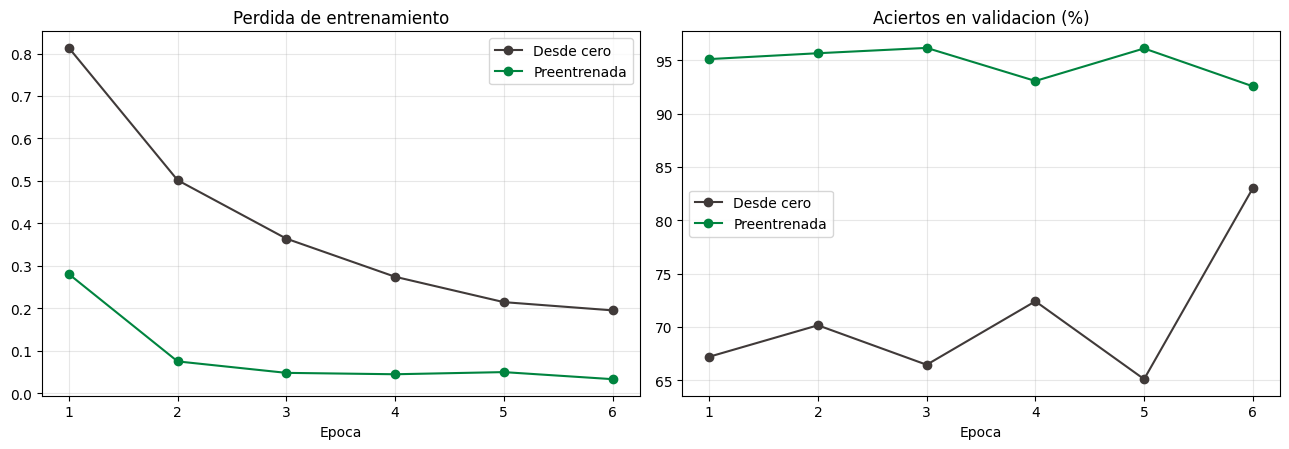

Red                     Mejor validacion
----------------------------------------
Sin entrenar                      10.3%
Desde cero                        83.0%
Preentrenada                      96.2%


In [42]:
# @title El veredicto: tabla y curvas comparativas
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ep = range(1, CFG["epochs"] + 1)
axes[0].plot(ep, hist_cero["loss"], marker="o", color="#403A39", label="Desde cero")
axes[0].plot(ep, hist_pre["loss"],  marker="o", color="#00843F", label="Preentrenada")
axes[0].set_title("Perdida de entrenamiento"); axes[0].set_xlabel("Epoca"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, [v*100 for v in hist_cero["val"]], marker="o", color="#403A39", label="Desde cero")
axes[1].plot(ep, [v*100 for v in hist_pre["val"]],  marker="o", color="#00843F", label="Preentrenada")
axes[1].set_title("Aciertos en validacion (%)"); axes[1].set_xlabel("Epoca"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'Red':<22}{'Mejor validacion':>18}")
print("-" * 40)
print(f"{'Sin entrenar':<22}{acc_sin_entrenar*100:>16.1f}%")
print(f"{'Desde cero':<22}{acc_cero*100:>16.1f}%")
print(f"{'Preentrenada':<22}{acc_pre*100:>16.1f}%")

<font color='blue' size="5">**Sample Output Example**</font>

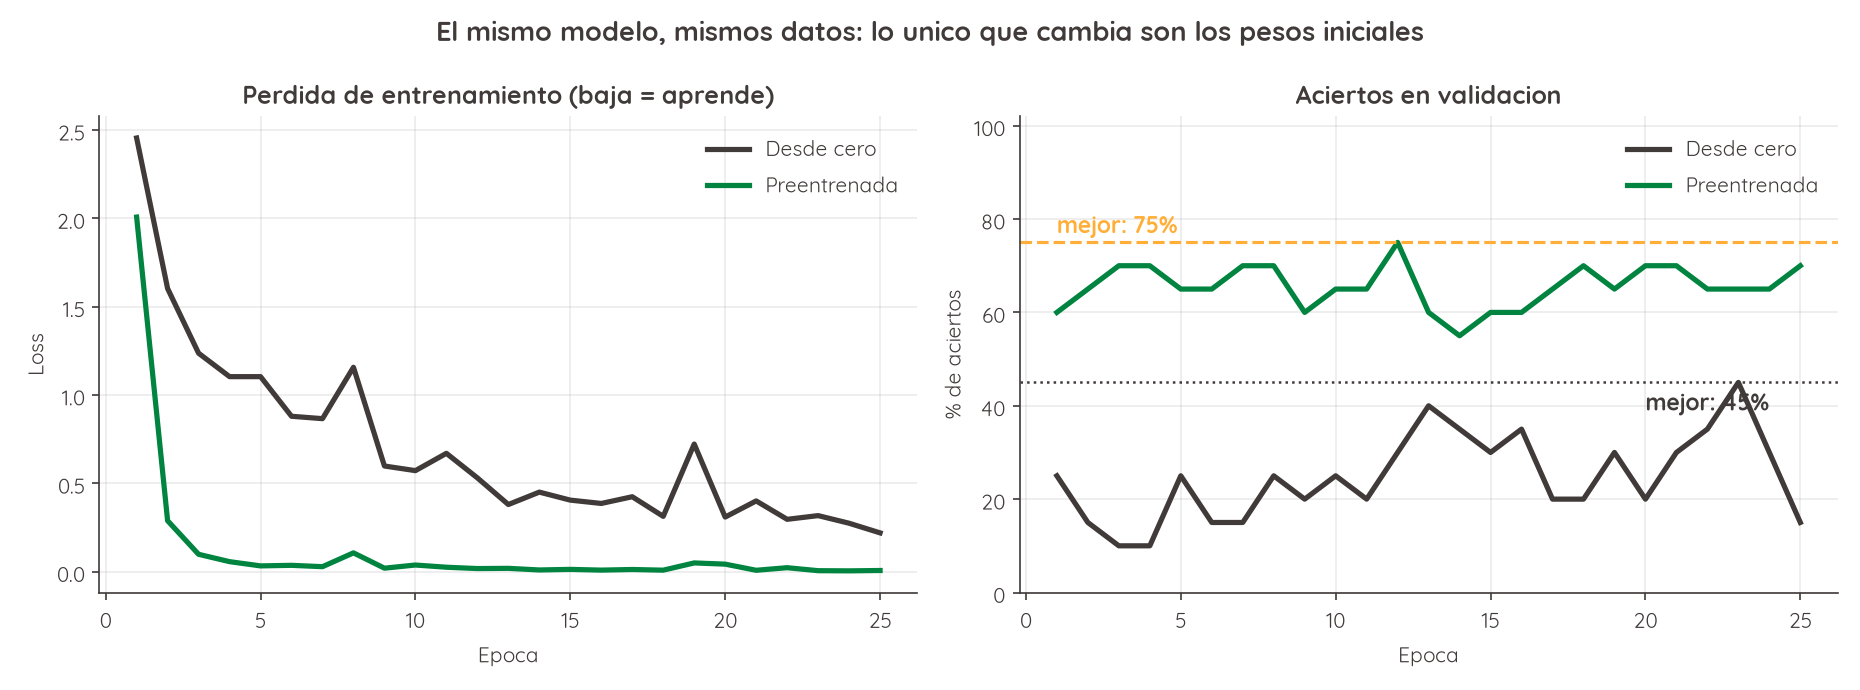

Esta figura es de una corrida miniatura de ejemplo (60 imagenes). La tuya en modo completo debe verse igual de contrastada pero con numeros mas altos: alrededor de 80% desde cero y 95% o mas la preentrenada.

## **TAREA - Medir la brecha**

#### **TASK**

Calcula `mejora`: cuantos **puntos porcentuales** le saco la preentrenada a la desde cero.

1. Resta los aciertos: `acc_pre - acc_cero`.
2. Multiplica por 100 para convertir a puntos.

In [43]:
# @title TU CODIGO - completa el None
mejora = (acc_pre-acc_cero)*100   # puntos porcentuales de ventaja de la preentrenada

if mejora is not None:
    print(f"La preentrenada le saco {mejora:.1f} puntos a la desde cero.")

La preentrenada le saco 13.2 puntos a la desde cero.


In [44]:
# @title Verificacion
verificar("numero de epocas de la preentrenada", len(hist_pre["val"]), CFG["epochs"])
verificar("la preentrenada supera el umbral de tu modo",
          bool(acc_pre >= CFG["pre_min"]), True)
verificar("mejora bien calculada",
          None if mejora is None else round(float(mejora), 1),
          round((acc_pre - acc_cero) * 100, 1), tol=0.11)
verificar("la preentrenada le gano a la desde cero", bool(acc_pre > acc_cero), True)

OK       | numero de epocas de la preentrenada: 6
OK       | la preentrenada supera el umbral de tu modo: True
OK       | mejora bien calculada: 13.2
OK       | la preentrenada le gano a la desde cero: True


True

# **Tarea 5: Juega con tu red**

Tu red preentrenada ya esta lista. Ponla a prueba: **mueve el deslizador** para elegir una imagen de validacion y mira que dice. Ejecuta la celda cada vez que cambies el numero. Intenta encontrar una en la que se equivoque.

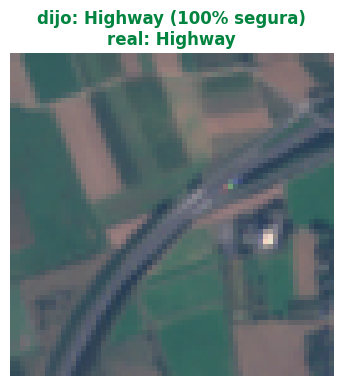

ACERTO


In [45]:
# @title Elige una imagen y mira la prediccion (mueve el deslizador y ejecuta)
IMAGEN = 3  # @param {type:"slider", min:0, max:19, step:1}

i = int(IMAGEN)
red_pre.eval()
with torch.no_grad():
    salida = red_pre(X_val[i:i+1].to(device))
    probs = torch.softmax(salida, dim=1)[0].cpu()
pred = int(probs.argmax())
real = int(y_val[i])

vis = full_val[int(idx_va[i])]["image"]
rgb = (vis[[3, 2, 1], :, :] / 3000.0).clamp(0, 1).permute(1, 2, 0).numpy()
plt.figure(figsize=(4.2, 4.2))
plt.imshow(rgb); plt.axis("off")
acerto = pred == real
plt.title(f"dijo: {full_val.classes[pred]} ({probs[pred]*100:.0f}% segura)\nreal: {full_val.classes[real]}",
          color=("#00843F" if acerto else "#B8641B"), fontweight="bold")
plt.show()
print("ACERTO" if acerto else "FALLO... encontraste una dificil")

# **Tarea 6: Evaluacion**

**Note:** ejecuta esta celda al final, cuando todo este completo. **La meta es 14 de 14** (en modo completo, que es el de la entrega).

In [46]:
# @title Resumen de verificaciones (ejecutar al final)
total = len(REGISTRO)
buenas = sum(1 for v in REGISTRO.values() if v)
print("=" * 56)
print(f"  VERIFICACIONES SUPERADAS: {buenas} de {total}  (meta: 14 de 14)")
print(f"  MODO: {MODO}  (la entrega oficial es en modo completo)")
print("=" * 56)
if total < 14:
    print("\nAun no has ejecutado todas las celdas de verificacion.")
pend = [n for n, v in REGISTRO.items() if not v]
if pend:
    print("\nPendientes o incorrectas:")
    for n in pend:
        print("  -", n)
elif total >= 14 and MODO == "completo":
    logro("SEMANA 2 COMPLETA - ya entrenas redes neuronales de verdad")

  VERIFICACIONES SUPERADAS: 14 de 14  (meta: 14 de 14)
  MODO: completo  (la entrega oficial es en modo completo)

  LOGRO DESBLOQUEADO: SEMANA 2 COMPLETA - ya entrenas redes neuronales de verdad


<font color='blue' size="5">**Sample Output Example**</font>

```
========================================================
  VERIFICACIONES SUPERADAS: 14 de 14  (meta: 14 de 14)
  MODO: completo  (la entrega oficial es en modo completo)
========================================================

========================================================
  LOGRO DESBLOQUEADO: SEMANA 2 COMPLETA - ya entrenas redes neuronales de verdad
========================================================
```

# **Tarea 7: Resumen y recomendacion**

**Note:** sigue las instrucciones con cuidado y completa las secciones faltantes.

Escribe tu **Resumen y Recomendacion** para el equipo de Smartgrow.

**Instructions:**

**1. Tus tres numeros:**

* Sin entrenar, desde cero y preentrenada: escribelos y di que significa cada salto.

**2. Tus apuestas:**

* Que tan cerca quedaron tus dos apuestas y que aprendiste de eso.

**3. El porque:**

* Con tus palabras: por que la preentrenada gana si es exactamente la misma arquitectura?

**4. Recomendacion final:**

* Si Smartgrow va a entrenar un clasificador de cultivos con pocos datos etiquetados, que le recomiendas: desde cero o transfer learning? Por que?

`<Escribe aqui tu resumen>`
**1.-Mis numeros:** Sin entrenar: 10.3%, desde cero: 83% y entrenada 96.2%. El primer salto esta hecho por entrenar de manera minima el modelo, esto dado por la parte de la actividad en la implementabamos los tres pasos, en el corazón del modelo, que basicamente era lo de limpiar y ajustar el gradiente.
**2.Mis apuestas:**-Mi primera apuesta si la verdad la hice con mucho entusiasmo jajaja, si creía que un modelo sin entrenar podía llegar a un 50% pero ya la segunda si lo hice mas consciente y casi acerte o al menos estuve por debajo apenas unos puntos, y aprendí mucho la diferencia entre una red solo construida y otra entrenada y construida.
**3.-Mi porque: **Aquí diferiria en decir exactamente porque se que pasa esto, pero con ayuda de una IA entendí que es por los pesos, como la red desde cero comienza con pesos aleatorios y debe aprender todas las características visuales únicamente con los datos disponibles.
**4. Recomendación:** Yo diría que Transfer learning, porque esto nos permite que los pocos datos etiquetados se utilicen con mayor "confianza" en vez de tratar que una red aprenda desde cero caracteristicas que ya pudo haber conocido.

<font color='blue' size="5">**Sample Output Example**</font>

> EJEMPLO (escribelo con tus palabras, no lo copies):
>
> 1. **Mis numeros:** sin entrenar 9.5% (azar), desde cero 81%, preentrenada 96%. El primer salto lo dio el entrenamiento; el segundo, los pesos de ImageNet.
> 2. **Mis apuestas:** aposte 50% y 85%. Subestime lo malo que es el azar y lo buena que es la ventaja del preentrenamiento.
> 3. **El porque:** la preentrenada ya sabia ver bordes y texturas por haber visto 1.2 millones de fotos; solo tuvo que aprender que forma tiene un cultivo.
> 4. **Recomendacion:** con pocos datos etiquetados, siempre transfer learning: llega mas alto, mas rapido y con menos datos. Desde cero solo tendria sentido con millones de imagenes propias.

---
## **Antes de entregar**

- [ ] Corriste en **modo completo con GPU** y la Tarea 6 reporta **14 de 14**.
- [ ] El notebook corre completo de un tiron: **Entorno de ejecucion**, **Reiniciar y ejecutar todo**, sin errores.
- [ ] Tu tabla comparativa muestra las tres redes y la preentrenada gana.
- [ ] Las respuestas escritas de la Tarea 7 van con tus palabras y TUS numeros.
- [ ] Guardado en el repo como `notebooks/S2_primera_red_TUNOMBRE.ipynb`, con tu commit y push.
- [ ] Horas registradas en `hours.csv` con el link a tu commit.

**Recuerda: horas sin evidencia no cuentan. Tu evidencia de esta semana es tu commit.**

---

*Smartgrow ML Lab - Semana 2 de 14 - Tec de Monterrey*